In [1]:
import numpy as np
import scipy.optimize
import corner
import emcee

import matplotlib.pyplot as plt

# Define our plotting and analysis functions

* Below are the general workhorses of the fitting we will do.
* Since they are common to everything we will do in these solutions, we've written to be general, so they can be written just once and then called multiple times.
* This is generally good practice when writing code---avoiding repeated codes means avoiding repeated bugs, or bugs introduced in reimplementing something.
* I have added extensive comments below to try to help you through in understanding the solution.
* These are examples of functions that could go into a package that you might import. Indeed there are (slightly different) versions of these already in the course tools package. 

In [2]:

def plot_data(x, y, y_err, models=None, subtract_y=None,
              axis_labels=["$x$", "$y$"], **data_kwargs):
    """
    Create a set of summary plots for a list of "models."
    The types of plots are inferred from the dictionary
    describing the model.

    For example, if `violin_samples` is a key in the dictionary
    of one of the models, then a violinplot will be made, e.g.
    to visualize the posterior predictive distribution. 
    
    Parameters:
    -----------
    x : np.ndarray
        x-values of the data
    y : np.ndarray
        y-values of the data
    y_err : np.ndarray or float
        uncertainty on the y-values of the data
    models : list
        A list of models to plot information for. Each entry of this list
        is a dictionary that specifies information about the model. Below, we include
        the specification of what can be in this dictionary.
    subtract_y : np.ndarray or float
        An array of values or a single value to subtract 
        from all values of the data (a constant offset)
    axis_labels : list
        a list of strings, uses only the first two entries. The first for
        the x-axis the second for labeling the y-axis
    data_kwargs : dict
        a dictionary of keyword arguments that get passed to plotting functions
        like matplotlib.pyplot.plot.
        
    Returns:
    --------
    fig : plt.figure object
    ax : plt.axis object
    """

    
    fig, ax = plt.subplots()

    data_kwargs = {**data_kwargs}
    if "ls" not in data_kwargs and "linestyle" not in data_kwargs:
        data_kwargs["linestyle"] = "none"
    if "marker" not in data_kwargs:
        data_kwargs["marker"] = "."

    if subtract_y is None:
        subtract_y = np.zeros_like(y)
    ax.errorbar(x, y-subtract_y, y_err, **data_kwargs, label="Data")

    # set the width of the violin plots for the
    # posterior predictive plots
    def default_violin_width(x, scale=1.5, max_frac=0.1):
        """Violin width from mean x-spacing; overlap in clusters is tolerated."""
        x = np.unique(x)
        if x.size < 2:
            return 0.5
        span = x[-1] - x[0]
        return min(scale * span / (x.size - 1), max_frac * span)
        
    # loop 
    if models is not None:
        for model_def in models:
            if "lower" in model_def:
                ax.fill_between(
                    model_def["x"],
                    model_def["lower"], model_def["upper"],
                    **model_def.get("style", {})
                )
            elif "y_err" in model_def:
                ax.errorbar(
                    model_def["x"], model_def["y"], model_def["y_err"],
                    **model_def.get("style", {})
                )
            elif "violin_samples" in model_def:
                style = dict(model_def.get("style", {}))
                # pull apart what is a kwarg to ax.violinplot
                # and what has to be included separately
                # this is annoying because matplotlib's violinplots
                # are annoying.
                vp_kwargs = {k: style.pop(k) for k in
                             ("widths", "showmeans", "showmedians",
                              "showextrema", "quantiles", "points", "bw_method")
                             if k in style}
                vp_kwargs = {"showmeans": False, "showextrema": False, **vp_kwargs}
                vp_kwargs.setdefault("widths", default_violin_width(model_def["x"]))
                violin_plots = ax.violinplot(
                    dataset=model_def["violin_samples"],
                    positions=model_def["x"], **vp_kwargs
                )                
                for body in violin_plots["bodies"]:
                    body.set(**style)
                    if "label" in style:
                        del style["label"]

            else:
                ax.plot(
                    model_def["x"], model_def["y"],
                    **model_def.get("style", {})
                )

    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.legend(frameon=False)

    return fig, ax



def analyse_data(data,
                 log_posterior_fn, model_fn, predict_fn, ppd_test_statistic_fn=None,
                 param_names=None,
                 derived_parameter_fn=None, derived_parameter_names=[],
                 derived_parameter_true=[],
                 theta_true=None,
                 theta_init=None, theta_init_std=None,
                 plot=True, model_x=None,
                 n_step_emcee=5000, n_ppd=500):
    """
    Implement a Bayesian workflow on 1-dimensional data that contains
    an independent variable (x), a dependent variable (y) and uncertainty
    on the measured dependent variable (y_err). 

    It first calculaes a maximum a posteriori value for the parameters using scipy.optimize.
    
    Then it uses Markov chain Monte Carlo to produce samples distributed according
    to the posterior distribution on the parameters of the model (using the 
    emcee package). 

    Subsequently, it calculates model predictive and posterior predictive distributions,
    plots them, and performs a posterior predictive check if there is a function
    that is supplied to do so (`ppd_test_statistic`, discussed in detail Week 7).

    Parameters:
    -----------
    log_posterior_fn : Callable function
        A callable function that takes in (theta, x, y_err, y) where
        theta is the list of free parameters.
    model_fn : Callable function
        A callable function that takes in (theta, x) as parameters
        and returns an estimate of y. 
    predict_fn : Callable function
        A callable function that takes in (theta, x, y_err, y) and produces
        predicted data from that model (simulates data from the likelihood, given
        a set of parameters).
    ppd_test_statistic_function : Callable function
        Takes in (y, theta, x, sigma_y) and produces a single summary statistic
        that can be used to compare replicated (posterior predictive) data with real data.
    derived_parameter_fn : Callable function
        If there are interesting parameters that are deterministically derived from the
        parameters that we sample, then they are defined here.
    derived_parameter_names : list
        A list of the names of the derived parameters output from `derived_parameter_fn`
    derived_parameter_true : list
        A list of the *true* derived parameters (if known)
    theta_true : np.ndarray, or list
        A list of the true parameters that were sampled (if known)
    theta_init : np.ndarray
        The initial values for the sampled parameters at the start of MCMC sampling
    theta_std : np.ndarray
        We can initialize the sampler around theta_init with some standard deviation.
    plot : bool
        True to make summary plots. False to not make them. 
    n_step_emcee : int, default=5000
        number of MCMC steps to take
    n_ppd : int, default=500
        number of posterior samples on which to calculate ppd_test_statistic

    Returns:
    --------
    results : dict
        A results dictionary containing samples, true values, posterior fit information
        and (if supplied) posterior predictive checking information.
    """

    x, y, sigma_y = data["x"], data["y"], data["y_err"]

    # MCMC initialization
    if theta_init is None:
        theta_init = theta_true
    theta_init = np.array(theta_init)

    if theta_init_std is None:
        theta_init_std = 0.1*theta_init
        theta_init_std[theta_init_std == 0.0] = 0.1

    # names of parameters
    if param_names is None:
        param_names = [f"p_{i}" for i in range(theta_init.size)]

    if model_x is None:
        model_x = x

    if theta_true is not None:
        true_model_plot_def = [dict(
            x=model_x, y=model_fn(theta_true, model_x),
            style=dict(color="black", ls="--", label="True model")
        )]
    else:
        true_model_plot_def = []

    # Find the MAP
    def negative_log_posterior(theta, x, sigma_y, y):
        return -log_posterior_fn(theta, x, sigma_y, y)

    MAP_result = scipy.optimize.minimize(
        fun=negative_log_posterior,
        x0=theta_init,
        args=(x, sigma_y, y)
    )
    theta_MAP = MAP_result.x

    print("MAP results")
    for name, theta in zip(param_names, theta_MAP):
        print(f"{name}_MAP = {theta}")


    # Sample posterior with emcee

    # emcee requires some extra settings to run
    n_param = len(theta_init) # Number of parameter we are sampling
    n_walker = 3*n_param      # Number of walkers. This just needs to be larger than 2*n_param + 1
    n_step = n_step_emcee     # How many steps each walker will take. The number of samples will be n_walker*n_step

    # The starting point for each walker
    theta_init = theta_init + theta_init_std*np.random.normal(size=(n_walker, n_param))

    # compute derived parameters while sampling
    if derived_parameter_fn is not None:
        log_posterior_wrapper = lambda *args: (log_posterior_fn(*args), derived_parameter_fn(args[0]))
    else:
        log_posterior_wrapper = log_posterior_fn
    sampler = emcee.EnsembleSampler(
        nwalkers=n_walker, ndim=n_param,
        log_prob_fn=log_posterior_wrapper,
        args=(x, sigma_y, y)
    )
    state = sampler.run_mcmc(theta_init, nsteps=n_step, progress=True)

    # The samples will be correlated, this checks how correlated they are
    # We will discuss this once we come to MCMC methods
    integrated_autocorr_time = sampler.get_autocorr_time(quiet=True)
    print("Auto-correlation time of chain:")
    for name, value in zip(param_names, integrated_autocorr_time):
        print(f"{name} = {value:.1f}")

    max_autocorr_time = max(integrated_autocorr_time)

    # We need to discard the beginning of the chain (a few auto-correlation times)
    # to get rid of the initial conditions
    burn_in_config = dict(
        discard=int(5*max_autocorr_time),
        thin=int(max_autocorr_time/2),
        flat=True
    )
    chain = sampler.get_chain(
        **burn_in_config
    )

    # Make predictive distributions
    # Choose a small subsample of the chain for plotting purposes
    chain_samples = chain[np.random.choice(chain.shape[0], size=n_ppd)]
    # Evaluate the model at the sample parameters
    model_predictive = np.array(
        [model_fn(sample, model_x) for sample in chain_samples]
    )
    model_quantiles = np.quantile(
        model_predictive, q=[0.025, 0.16, 0.84, 0.975], axis=0
    )

    posterior_predictive = np.array(
        [predict_fn(sample, x, sigma_y) for sample in chain_samples]
    )
    posterior_predictive_quantiles = np.quantile(
        posterior_predictive, q=[0.025, 0.16, 0.84, 0.975], axis=0
    )

    if ppd_test_statistic_fn is not None:
        T_rep = np.array(
            [ppd_test_statistic_fn(y_rep, sample, x, sigma_y)
             for y_rep, sample in zip(posterior_predictive, chain_samples)]
        )
        T_data = np.array(
            [ppd_test_statistic_fn(y, sample, x, sigma_y)
             for sample in chain_samples]
        )
        goodness_of_fit_pte = np.sum((T_rep - T_data) > 0)/len(T_rep)

        print(f"Posterior predictive p-value: {goodness_of_fit_pte:.2g} "
              f"(T_rep = {np.mean(T_rep):.2g}±{np.std(T_rep):.2g}, "
              f"T_data = {np.mean(T_data):.2g}±{np.std(T_data):.2g})"
        )

    if derived_parameter_fn is not None:
        blobs = sampler.get_blobs(
            **burn_in_config
        )
        if blobs.ndim == 1:
            blobs = blobs.reshape(-1, 1)
        chain = np.concatenate((chain, blobs), axis=-1)

    print("Posterior results (mean±std)")
    for i, name in enumerate(param_names + derived_parameter_names):
        print(f"{name} = {np.mean(chain[:,i]):.2g}±{np.std(chain[:,i]):.2g}")

    if plot:
        # Make a corner plot
        fig = plt.figure()
        fig = corner.corner(
            chain,
            bins=40,
            labels=param_names + derived_parameter_names,
            truths=theta_true + derived_parameter_true,
            levels=1-np.exp(-0.5*np.array([1, 2])**2), # Credible contours corresponding to 1 and 2 sigma in 2D
            quantiles=[0.025, 0.16, 0.84, 0.975],
            fig=fig
        )
        plot_data(
            x=x, y=y, y_err=sigma_y,
            models=[
                dict(x=model_x, y=model_fn(theta_MAP, model_x),
                    style=dict(color="C2", label="MAP model")),
                
                dict(x=model_x, lower=model_quantiles[0], upper=model_quantiles[-1],
                    style=dict(color="C1", alpha=0.5, label="Model predictions")),
                dict(x=model_x, lower=model_quantiles[1], upper=model_quantiles[-2],
                    style=dict(color="C1", alpha=0.5)),
                dict(x=x, violin_samples=posterior_predictive,
                     style=dict(color="grey", alpha=0.5, label="Posterior predictions")),
            ] + true_model_plot_def,
            marker=".", linestyle="none"
        )
        # plot our posterior predictive test statistic
        if ppd_test_statistic_fn is not None:
            fig = plt.figure(figsize=(6, 6))
            gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], height_ratios=[1, 2],
                                  hspace=0.05, wspace=0.05)
            ax = fig.add_subplot(gs[1, 0])
            ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
            ax_right = fig.add_subplot(gs[1, 1], sharey=ax)
        
            lims = [min(T_data.min(), T_rep.min()), max(T_data.max(), T_rep.max())]
            # edges = np.linspace(*lims, bins + 1)
        
            ax.scatter(T_data, T_rep, s=5, alpha=0.5)
            ax.plot(lims, lims, "k--", lw=1, label="$y = x$")
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            ax.set_xlabel(r"$T(y, \theta)$")
            ax.set_ylabel(r"$T(y_\mathrm{rep}, \theta)$")
            ax.legend(frameon=False, loc="upper left")
        
            ax_top.hist(T_data, bins='auto', alpha=0.5)
            ax_right.hist(T_rep, bins='auto', alpha=0.5, orientation="horizontal")
            ax_top.tick_params(labelbottom=False)
            ax_right.tick_params(labelleft=False)
            ax_top.set_title(f"$p = {goodness_of_fit_pte:.2g}$")
            

    return dict(
        MAP=theta_MAP,
        PPD=posterior_predictive,
        TPD=model_predictive,
        PPD_params=chain_samples,
        chain=chain
    )

# Fit the line from the lecture

* Load data from "../lectures/data/linear_fits/data_0.txt"
* Set the uncertainty to be fixed.
* Define a model, a Gaussian likelihood, and a prior
    * In all cases we use $\theta$ to define the parameter vector and we unpack it. This is a nice convention to use, in general, as we can write `analyse_data()` to ingest functions that have this call signature. 

In [3]:
m_true = 1.3
b_true = -0.2

# load data from lecture
x, y, y_err = np.loadtxt("../lectures/data/linear_fits/data_0.txt", unpack=True)
# For now, all error are the same
sigma_y = y_err[0]

In [4]:
# define the line here
def model(theta, x):
    m, b = theta
    return m*x + b

# We use the logarithm here for computational reasons
def log_likelihood(theta, x, sigma_y, y):
    prediction = model(theta, x)

    n = len(y)
    return (
        -0.5 * np.sum((y - prediction)**2/sigma_y**2)      # Exponent
        - n/2*np.log(2*np.pi*sigma_y**2)                   # Normalisation
    )

# here is our prior
def log_prior(theta):
    m, b = theta
    mu_m = -1
    mu_b = 1

    sigma_m = 1
    sigma_b = 1.2

    return (
        -0.5*(m-mu_m)**2/sigma_m**2      # m exponent
        -0.5*(b-mu_b)**2/sigma_b**2      # b exponent
        - 0.5*np.log(2*np.pi*sigma_m**2) # Normalisation
        - 0.5*np.log(2*np.pi*sigma_b**2) # Normalisation
    )

# log of product of prior and likelihood is the sum of the logs
def log_posterior(theta, x, sigma_y, y):
    return log_likelihood(theta, x, sigma_y, y) + log_prior(theta)

# Predict new data, given parameters
def predict(theta, x, sigma_y, size=None):
    mu = model(theta, x)
    return np.random.normal(loc=mu, scale=sigma_y, size=size)

# look at how to call this function
?analyse_data

Signature:
analyse_data(
    data,
    log_posterior_fn,
    model_fn,
    predict_fn,
    ppd_test_statistic_fn=None,
    param_names=None,
    derived_parameter_fn=None,
    derived_parameter_names=[],
    derived_parameter_true=[],
    theta_true=None,
    theta_init=None,
    theta_init_std=None,
    plot=True,
    model_x=None,
    n_step_emcee=5000,
    n_ppd=500,
)
Docstring:
Implement a Bayesian workflow on 1-dimensional data that contains
an independent variable (x), a dependent variable (y) and uncertainty
on the measured dependent variable (y_err). 

It first calculaes a maximum a posteriori value for the parameters using scipy.optimize.

Then it uses Markov chain Monte Carlo to produce samples distributed according
to the posterior distribution on the parameters of the model (using the 
emcee package). 

Subsequently, it calculates model predictive and posterior predictive distributions,
plots them, and performs a posterior predictive check if there is a function
that is su

## Analyze the data

We pass the functions defined above to the `analyse_data` function.

We can see the reproduced plots from the lecture, including the corner plot and the posterior predctive and model predictive compared to the true and MAP models. 

MAP results
m_MAP = 1.2211022384719732
b_MAP = -0.11088757118016776


100%|███████████████████████| 5000/5000 [00:00<00:00, 8440.75it/s]


Auto-correlation time of chain:
m = 35.2
b = 34.9
Posterior results (mean±std)
m = 1.2±0.11
b = -0.11±0.12


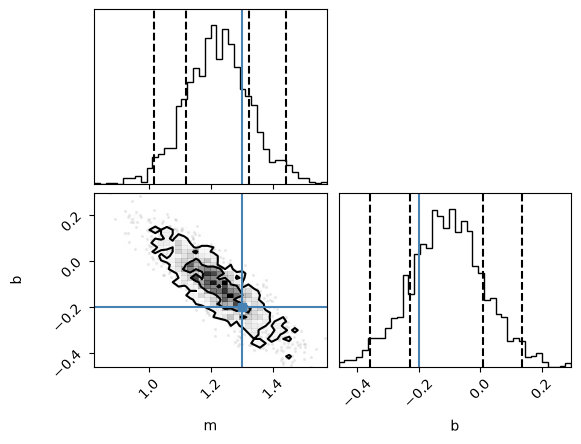

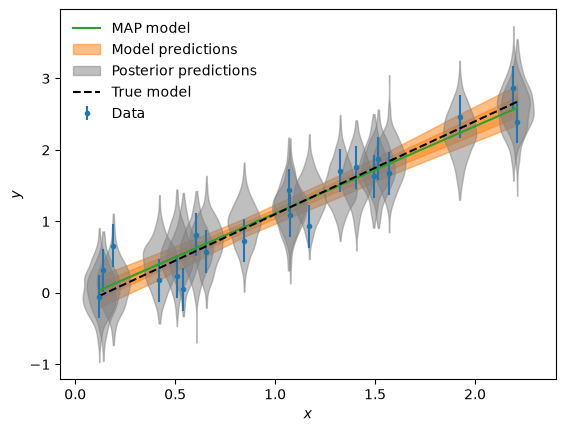

In [5]:
output_result = analyse_data(
    data=dict(x=x, y=y, y_err=sigma_y),
    log_posterior_fn=log_posterior,
    model_fn=model,
    predict_fn=predict,
    param_names=["m", "b"],
    theta_true=[m_true, b_true],
)

# Fitting a line with different uncertainties for each measurement

Now we load the next linear fit data that contains different true parameters
and a different model for the uncertainty. 
\begin{align}
    \mu(x) &= mx + b \\
    \sigma(x_i) &= \sigma_{y_i} + f\mu(x_i)^2 \quad f > 0\ \text{a parameter} \\
    y_i&\sim\mathcal N(\mu(x_i),\sigma(x_i)^2)
\end{align}

## Using the wrong likelihood

First, though, we won't scale the uncertainty, we'll just pass it as it comes out
of the file, and see what happens.

We can see from the model predictive and the posterior predictive that things don't look very good.

In [6]:
# Load the data
x, y, y_err = np.loadtxt("../lectures/data/linear_fits/data_1.txt", unpack=True)

m_true, b_true = -0.7, 1.2
f_true = 0.51

In [7]:
# Because the error is now different for each data point, we need to adapt the
# likelihood a bit
def log_likelihood_heteroscedastic(theta, x, sigma_y, y):
    prediction = model(theta, x)

    return (
        -0.5 * np.sum((y - prediction)**2/sigma_y**2)    # Exponent
        -0.5 * np.sum(np.log(2*np.pi*sigma_y**2))        # Normalisation
    )

def log_posterior_heteroscedastic(theta, x, sigma_y, y):
    return log_likelihood_heteroscedastic(theta, x, sigma_y, y) + log_prior(theta)


MAP results
m_MAP = -0.3614544936159469
b_MAP = 0.6994697875874143


100%|██████████████████████| 5000/5000 [00:00<00:00, 10515.66it/s]


Auto-correlation time of chain:
m = 35.1
b = 32.6
Posterior results (mean±std)
m = -0.36±0.041
b = 0.7±0.05


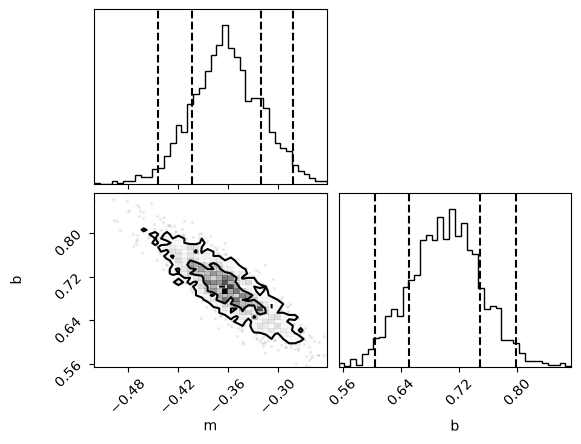

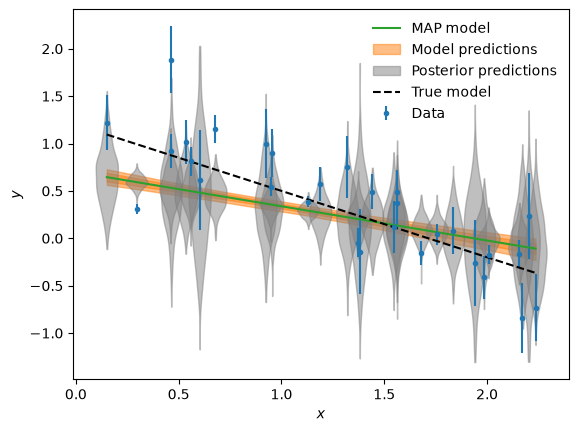

In [8]:
output_heteroscedastic = analyse_data(
    data=dict(x=x, y=y, y_err=y_err),
    log_posterior_fn=log_posterior_heteroscedastic,
    model_fn=model,
    predict_fn=predict,
    param_names=["m", "b"],
    theta_true=[m_true, b_true],
)

## Using the correct likelihood

Now instead let's implement the scaling that was supplied for the uncertainty in the likelihood. And we see that things look much better than before. The corner plot marginals are centered on the true injected parameters, and the model and posterior predictive look much better.


MAP results
m_MAP = -0.7355425584965917
b_MAP = 1.2885817199053355
f_MAP = 0.29532331062475015


100%|███████████████████████| 5000/5000 [00:00<00:00, 8770.49it/s]


Auto-correlation time of chain:
m = 43.7
b = 44.1
f = 57.7
Posterior results (mean±std)
m = -0.72±0.1
b = 1.3±0.17
f = 0.39±0.18


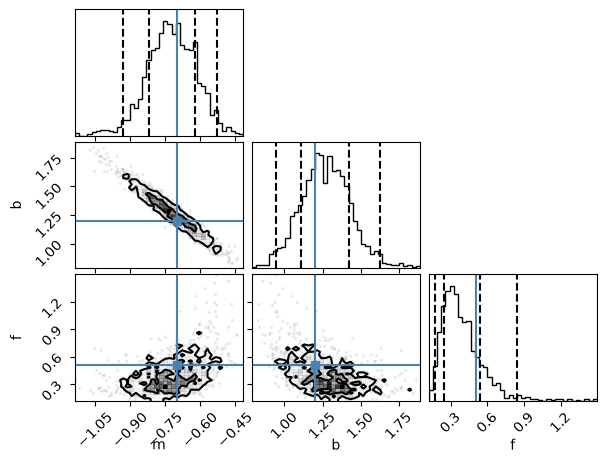

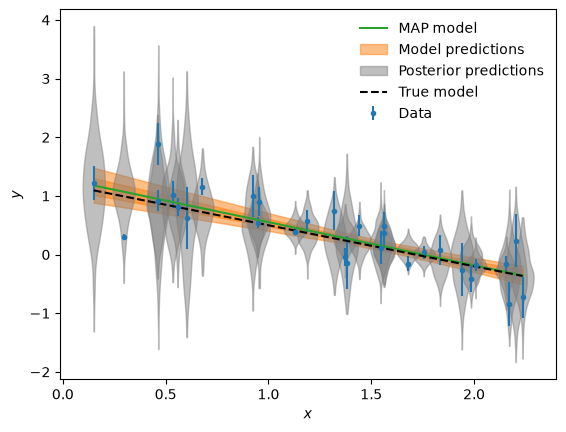

In [9]:
def log_likelihood_true(theta, x, sigma_y, y):
    m, b, f = theta
    prediction = model([m, b], x)

    sigma = sigma_y + f*prediction**2
    n = len(y)
    return (
        -0.5 * np.sum((y - prediction)**2/sigma**2)   # Exponent
        -0.5 * np.sum(np.log(2*np.pi*sigma**2))       # Normalisation
    )

def log_prior_true(theta):
    m, b, f = theta
    mu_f = 0.5
    sigma_f = 1

    return log_prior([m, b]) - 0.5*(f - mu_f)**2/sigma_f**2

def log_posterior_true(theta, x, sigma_y, y):
    return log_likelihood_true(theta, x, sigma_y, y) + log_prior_true(theta)

def predict_true(theta, x, sigma_y):
    m, b, f = theta
    mu = model([m, b], x)
    sigma = sigma_y + f*mu**2
    return np.random.normal(loc=mu, scale=sigma)

f_true = 0.51

output_true = analyse_data(
    data=dict(x=x, y=y, y_err=y_err),
    log_posterior_fn=log_posterior_true,
    model_fn=lambda theta, x: model(theta[:2], x),
    predict_fn=predict_true,
    param_names=["m", "b", "f"],
    theta_true=[m_true, b_true, f_true],
)


# Fitting Europa data

Now we'll load data for Europa and perform a similar analysis as in the lecture.

However, here, we'll look at the two different distance stimates `distance` and `distance_alt` and naively use their difference to inflate our error bars:

`sigma_distance = np.sqrt(distance_err**2 + (distance_alt-distance)**2)`.

In [10]:
moon = "Europa"

t, distance, distance_alt, distance_err = np.loadtxt(
    f"../lectures/data/jovian_moons/{moon}.dat", unpack=True)

# Literature values
theta_true = dict(
    Io=[0.421700, 1.769*24, 2.935632897970926],
    Ganymede=[1.070400, 7.155*24, 1.5793369771861996],
    Europa=[0.671100, 3.551*24, 3.0779939041348796],
    Callisto=[1.882700, 16.689*24, 1.9374307501130097],
)

Text(0.5, 1.0, 'Europa')

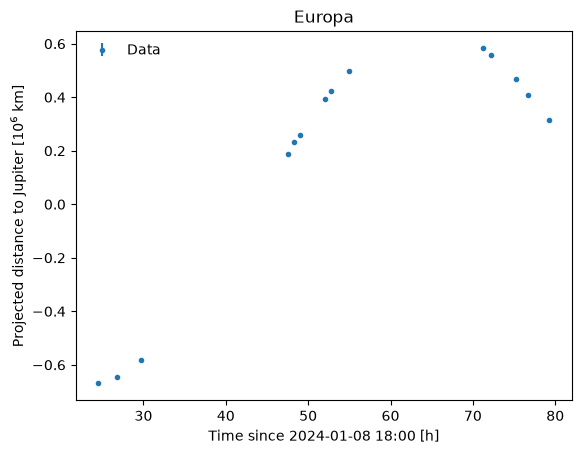

In [11]:
fig, ax = plot_data(
    x=t,
    y=distance,
    y_err=distance_err,
    linestyle="none",
    marker=".",
    axis_labels=["Time since 2024-01-08 18:00 [h]", "Projected distance to Jupiter [$10^6$ km]"],
)
ax.set_title(moon)

## Building our model

* We'll just let the prior be flat. In this case, we can make it unnormalized even,
because we don't particularly care about the overall normalization (we will if we do model selection where we need the marginal likelihood)

* Note that we have the same signature for these functions as we did before, so we can use that `analyse_data` function.

In [12]:

# Set up all the necessary functions in on go, based on a model for the mean,
# log_prior, and optional variance model:
def build_inference_model(model_fn, log_prior_fn=None, variance_model_fn=None):
    # flat prior
    if log_prior_fn is None:
        log_prior_fn = lambda theta: 0
        
    # change the variance if a function is supplied
    # otherwise just return the square of the standard deviation
    # that is input
    if variance_model_fn is None:
        variance_model_fn = lambda sigma_y, theta, t: sigma_y**2
    
    def log_likelihood_fn(theta, t, sigma_y, y):
        # Gaussian log likelihood
        mu = model_fn(theta, t)
        sigma2 = variance_model_fn(sigma_y, theta, t)
        return -0.5*len(y)*np.log(2*np.pi) - 0.5*np.sum(np.log(sigma2)) - np.sum(0.5 * (y - mu)**2/sigma2)
    
    def log_posterior_fn(theta, t, sigma_y, y):
        # log posterior is log_likelihood + log_prior
        log_prior = log_prior_fn(theta)
        if not np.isfinite(log_prior):
            return -np.inf
        return log_likelihood_fn(theta, t, sigma_y, y) + log_prior

    def predict_fn(theta, x, sigma_y):
        # draw from our Gaussian likelihood
        # to produce new data, conditioned on 
        # a choice of parameters. 
        mu = model_fn(theta, x)
        sigma2 = variance_model_fn(sigma_y, theta, t)
        return np.random.normal(loc=mu, scale=np.sqrt(sigma2))

    def ppd_test_statistic_fn(y, theta, t, sigma_y):
        # Produce a summary statistic that is sensitive
        # to something we care about. In this case, overfitting. 
        # this is a simple chi^2 summary statistic. We will calculate this
        # on replicate data and on real data, across our posterior.
        mu = model_fn(theta, t)
        sigma2 = variance_model_fn(sigma_y, theta, t)
        return np.sum(0.5 * (y - mu)**2/sigma2)
    
    return log_posterior_fn, model_fn, predict_fn, ppd_test_statistic_fn

In [13]:
def base_model(theta, t):
    semimajor, period, phi = theta
    return semimajor * np.sin(2 * np.pi * t / period+phi)

## Derived parameters and our model

* Note below that we implement the "erorr inflation" because of the two distance estimates.
* We then run analyse data, and we find that the posteriors contain the true literature values.
* However...there's more to say about this. Look at the last plot. We calculated a chi^2 statistic on the real data for each draw from the posterior. We *also* did it for *replicated data consistent with the model*. And we find that the statistics *don't generally agree*. That's a red flag.
* In fact, we find a pretty extreme "posterior predictive p-value." We'll formalize this in Week 7's discussion of model checking. For more information, Chapter 6 of "Bayesian Data Analysis" by Gelman is a fantastic resource: https://sites.stat.columbia.edu/gelman/book/BDA3.pdf. 

MAP results
$a$_MAP = 0.67028653424488
$T$_MAP = 84.0793338260133
$\phi$_MAP = 3.0218819083375426


100%|███████████████████████| 5000/5000 [00:00<00:00, 8045.75it/s]


Auto-correlation time of chain:
$a$ = 47.9
$T$ = 45.0
$\phi$ = 49.8
Posterior predictive p-value: 0.97 (T_rep = 7.1±2.7, T_data = 2±1.3)
Posterior results (mean±std)
$a$ = 0.67±0.011
$T$ = 84±0.95
$\phi$ = 3±0.047
$M$ = 2e+27±1.2e+26


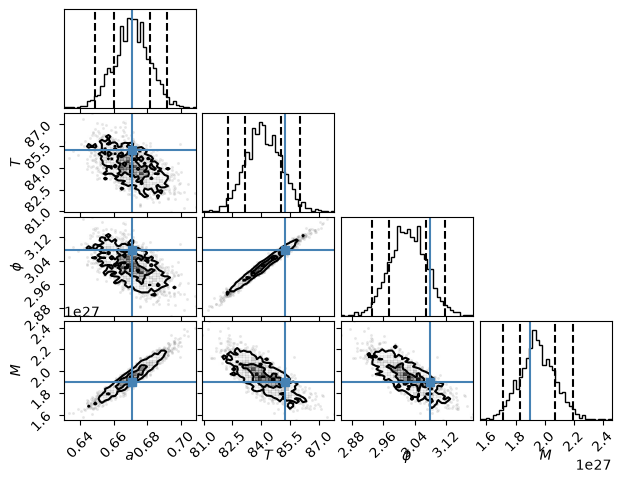

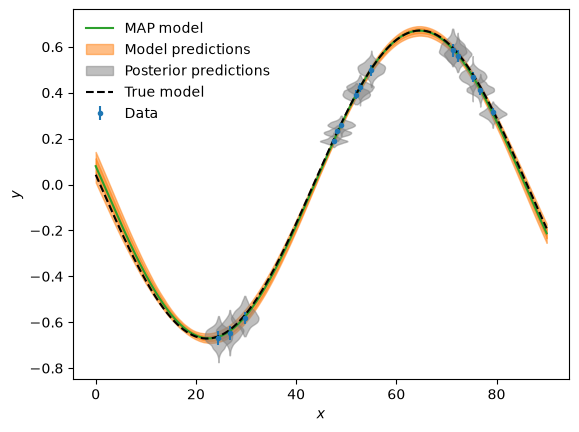

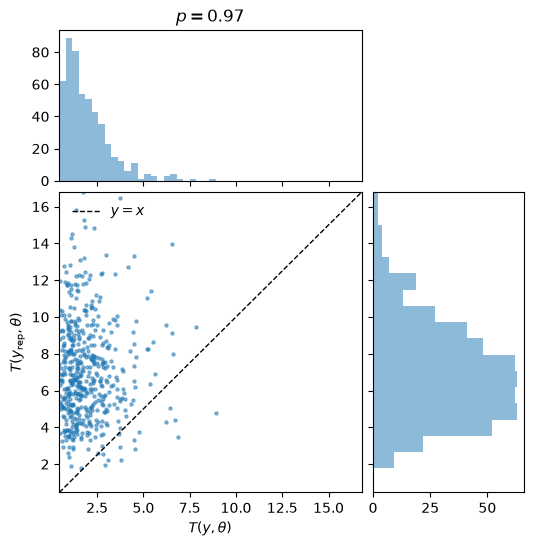

In [14]:
t_for_model = np.linspace(0, 90, 1000)

log_posterior, model, predict, ppd_test_statistic = build_inference_model(
    model_fn=base_model
)

# Inflate the uncertainty by the offset between the two distance estimates
distance_err_with_systematic = np.sqrt(distance_err**2 + (distance_alt-distance)**2)

data = dict(
    x=t, y=distance, y_err=distance_err_with_systematic
)

# derived parameter -- we want the mass based on the 
# measured semimajor axis and period. 
def mass_from_Kepler_3rd_law(theta):
    semimajor, period = theta[:2]
    return 4*(np.pi**2)/6.674e-11*((1e9*semimajor)**3)/((period*3600)**2)


results = analyse_data(
    data=data,
    log_posterior_fn=log_posterior,
    model_fn=model,
    predict_fn=predict,
    ppd_test_statistic_fn=ppd_test_statistic,
    param_names=["$a$", "$T$", "$\\phi$"],
    derived_parameter_fn=mass_from_Kepler_3rd_law,
    derived_parameter_names=["$M$"],
    derived_parameter_true=[1.8982e27],
    theta_true=theta_true[moon],
    theta_init=theta_true[moon],
    n_step_emcee=5000,
    model_x=t_for_model,
)

In [15]:
def plot_residuals(t, t_for_model, model_fn, distance, distance_err, results, true_model_fn, true_params):
    best_fit_model = model_fn(results["MAP"], t)
    best_fit_model_smooth = model_fn(results["MAP"], t_for_model)
    true_model_smooth = true_model_fn(true_params, t_for_model)

    model_quantiles = np.quantile(
        results["TPD"]-best_fit_model_smooth, q=[0.025, 0.16, 0.84, 0.975], axis=0
    )

    fig, ax = plot_data(
        x=t, y=distance-best_fit_model, y_err=distance_err,
        models=[
            dict(x=t_for_model, y=true_model_smooth-best_fit_model_smooth,
                style=dict(color="C3", ls="--", label="True model")),
            dict(x=t_for_model, lower=model_quantiles[0], upper=model_quantiles[-1],
                style=dict(color="C1", alpha=0.5, label="Model predictions")),
            dict(x=t_for_model, lower=model_quantiles[1], upper=model_quantiles[-2],
                style=dict(color="C1", alpha=0.5)),
            
            dict(x=t, violin_samples=results["PPD"] - best_fit_model,
                style=dict(color="grey", alpha=0.5, label="Posterior predictions")),
        ],
        marker=".", linestyle="none",
        axis_labels=["Time since 2024-01-08 18:00 [h]", "Residual projected distance to Jupiter [$10^6$ km]"],
    )
    ax.axhline(0, c="k", lw=1)


## Evaluate residuals
* We subtract off the MAP predictive model from everything here and see if things are centered around zero with the spread we expect.
* When I look at this, the blue points don't look spread out enough, based on their variance. All of them contain zero at 1-sigma. For 14 data points, that's very unlikely. Our error bars were too big. 

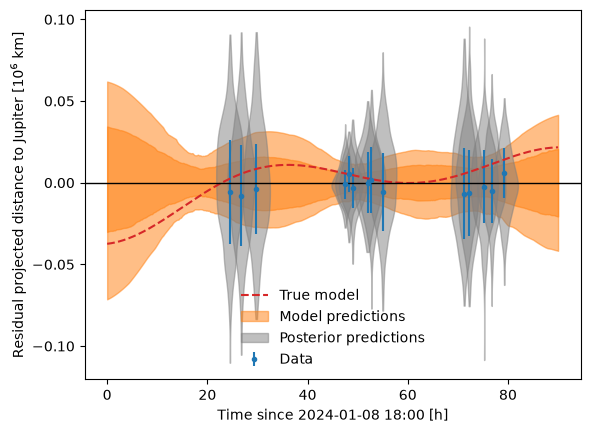

In [16]:

plot_residuals(
    t=t, t_for_model=t_for_model, model_fn=model,
    distance=distance, distance_err=distance_err_with_systematic,
    results=results, true_model_fn=base_model, true_params=theta_true[moon]
)

# Fitting an overall re-scaling of the variance

Instead of naively scaling the variance by the difference in our estimates, instead, let's add some extra variance but *make it an extra parameter that we fit*. In this case we call it `a_sys`. This will get fit as part of our Bayesian model. 

Now, when we do this, you can see from the corner plot that a_sys is peaked away from zero, so there's maybe a tiny bit more variance that we need. But it ends up being much less.

Unfortunately, our data is further from the true literature value, but that must mean we have some systematic error, not random error, that we haven't accounted for properly. So treating it as a random error isn't helping us.

Looking at the posterior predictive plot---that test statistic now looks similar on real data and replicated data. So we are fitting our data well, we are not over-inflating our error bars, etc.

Probably there is some issue with the data we were given. 

/Users/pmeyers/miniforge3/envs/stats_course/lib/python3.14/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/pmeyers/miniforge3/envs/stats_course/lib/python3.14/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


MAP results
$a$_MAP = 0.6710537235753485
$T$_MAP = 83.70965553051887
$\phi$_MAP = 3.0041422502204167
$a_\mathrm{sys}$_MAP = 0.0037699051508882525


100%|███████████████████████| 5000/5000 [00:00<00:00, 6435.32it/s]


Auto-correlation time of chain:
$a$ = 41.0
$T$ = 37.8
$\phi$ = 44.6
$a_\mathrm{sys}$ = 59.5
Posterior predictive p-value: 0.5 (T_rep = 7±2.7, T_data = 7±2.6)
Posterior results (mean±std)
$a$ = 0.67±0.0024
$T$ = 84±0.27
$\phi$ = 3±0.014
$a_\mathrm{sys}$ = 0.0052±0.0016
$M$ = 2e+27±2.8e+25


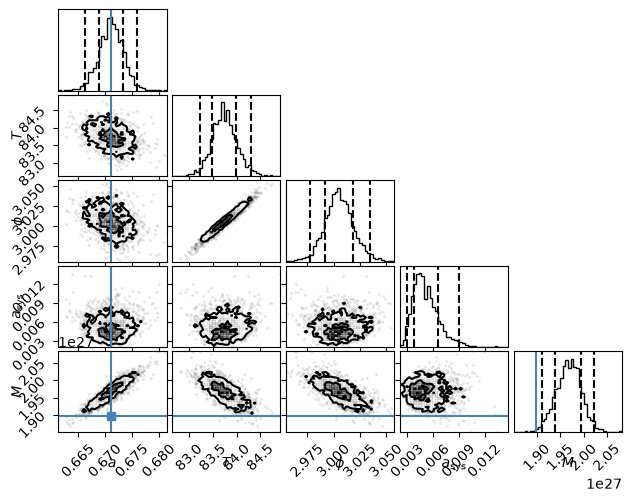

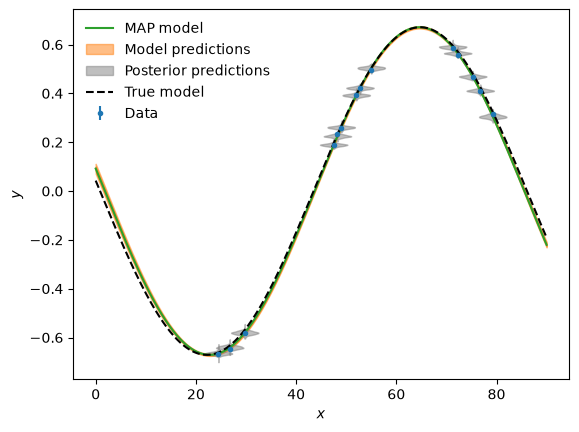

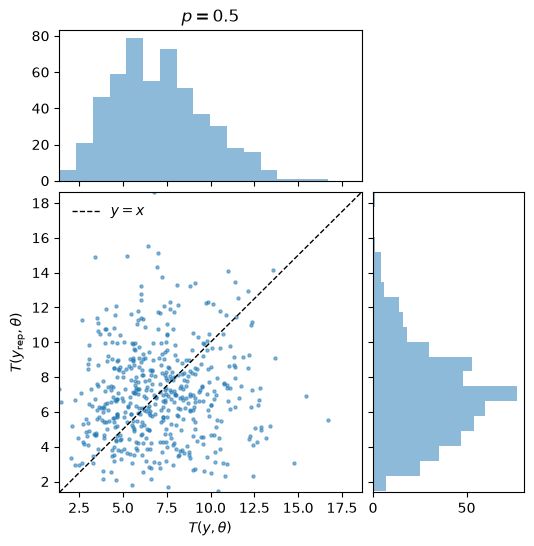

In [17]:
def sys_model(theta, t):
    semimajor, period, phi, a_sys = theta
    mu = base_model((semimajor, period, phi), t)
    return mu

def sys_variance_model(sigma_y, theta, t):
    # add our extra variance here. a_sys is a parameter, it lives in theta!
    semimajor, period, phi, a_sys = theta
    return sigma_y**2 + a_sys**2 

def log_sys_model_prior(theta):
    semimajor, period, phi, a_sys = theta
    if a_sys < 0:
        return -np.inf
    else:
        return 0.0


log_posterior, model, predict, ppd_test_statistic = build_inference_model(
    model_fn=sys_model, log_prior_fn=log_sys_model_prior, variance_model_fn=sys_variance_model
)

data = dict(
    x=t, y=distance, y_err=distance_err
)

results = analyse_data(
    data=data,
    log_posterior_fn=log_posterior,
    model_fn=model,
    predict_fn=predict,
    ppd_test_statistic_fn=ppd_test_statistic,
    param_names=["$a$", "$T$", "$\\phi$", "$a_\\mathrm{sys}$"],
    derived_parameter_fn=mass_from_Kepler_3rd_law,
    derived_parameter_names=["$M$"],
    derived_parameter_true=[1.8982e27],
    theta_true=theta_true[moon] + [None],
    theta_init=theta_true[moon] + [0.01],
    n_step_emcee=5000,
    model_x=t_for_model,
)

## Plot the residuals

* Now we see the blue points look more properly spread when using the MAP for the variance, as opposed to the inflated variance.
* The true model is outside of our model predictive, but that must be some indication of systematics that we haven't accounted for. In the end, our current model is a better one for the data than the one with inflated error bars. 

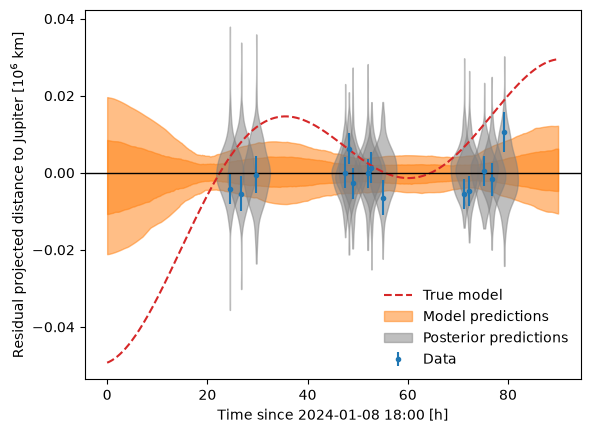

In [23]:

plot_residuals(
    t=t, t_for_model=t_for_model, model_fn=model,
    distance=distance, distance_err=np.sqrt(sys_variance_model(distance_err, results['MAP'], t)),
    results=results, true_model_fn=base_model, true_params=theta_true[moon]
)

# Analyze on distance_alt

* I could repeat the same thing on `distance_alt` instead of distance, but I think people know how to do this at this point :). 